# Human Activity Recognition using Smartphone Sensor Data

This notebook implements a multi-class human activity recognition (HAR) system using engineered accelerometer and gyroscope features from the UCI HAR dataset.

The objective is to classify six physical activities using supervised machine learning models and evaluate performance using stratified cross-validation and test-set analysis.

#Imports

In [32]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA

#Extract Dataset

In [33]:
zip_path = "/content/human+activity+recognition+using+smartphones.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset extracted successfully.")

Dataset extracted successfully.


## Dataset Description

- Source: UCI Human Activity Recognition Dataset
- 561 engineered features extracted from accelerometer and gyroscope signals
- 6 activity classes:
  - Walking
  - Walking Upstairs
  - Walking Downstairs
  - Sitting
  - Standing
  - Laying

#Load Dataset

In [34]:
# Load feature names
features = pd.read_csv(
    "/content/UCI HAR Dataset/features.txt",
    sep="\s+",
    header=None
)

feature_names = features[1].values

# Load training data
X_train = pd.read_csv(
    "/content/UCI HAR Dataset/train/X_train.txt",
    sep="\s+",
    header=None
)
X_train.columns = feature_names

y_train = pd.read_csv(
    "/content/UCI HAR Dataset/train/y_train.txt",
    header=None
)

# Load test data
X_test = pd.read_csv(
    "/content/UCI HAR Dataset/test/X_test.txt",
    sep="\s+",
    header=None
)
X_test.columns = feature_names

y_test = pd.read_csv(
    "/content/UCI HAR Dataset/test/y_test.txt",
    header=None
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3196557887.py:4: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",
/tmp/ipython-input-3196557887.py:13: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",
/tmp/ipython-input-3196557887.py:26: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


Train shape: (7352, 561)
Test shape: (2947, 561)


#Map Activity Labels

In [35]:
activity_labels = pd.read_csv(
    "/content/UCI HAR Dataset/activity_labels.txt",
    sep="\s+",
    header=None
)

label_map = dict(zip(activity_labels[0], activity_labels[1]))

y_train = y_train[0].map(label_map)
y_test = y_test[0].map(label_map)

print("Activities:", y_train.unique())

Activities: ['STANDING' 'SITTING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-260372875.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


# Model 1: Logistic Regression (Baseline)

We use Logistic Regression as a baseline linear classifier with feature standardization. This helps evaluate whether engineered features are linearly separable.

In [36]:
pipeline_log = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline_log.fit(X_train, y_train)

y_pred_log = pipeline_log.predict(X_test)

print("Logistic Regression Test Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Test Accuracy: 0.9552086868001357

Classification Report:

                    precision    recall  f1-score   support

            LAYING       1.00      0.99      1.00       537
           SITTING       0.97      0.88      0.92       491
          STANDING       0.89      0.97      0.93       532
           WALKING       0.94      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.94      0.96       420
  WALKING_UPSTAIRS       0.96      0.95      0.95       471

          accuracy                           0.96      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.96      0.96      2947



## Model 2: Random Forest

Random Forest is used as a non-linear ensemble model to compare performance against the linear baseline.

In [37]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Test Accuracy: 0.9267051238547676

Classification Report:

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.90      0.90       491
          STANDING       0.91      0.92      0.91       532
           WALKING       0.89      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.87      0.92       420
  WALKING_UPSTAIRS       0.89      0.89      0.89       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



#Model Comparison Table

In [38]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Model,Test Accuracy
0,Logistic Regression,0.955209
1,Random Forest,0.926705


#Confusion Matrix (Logistic)

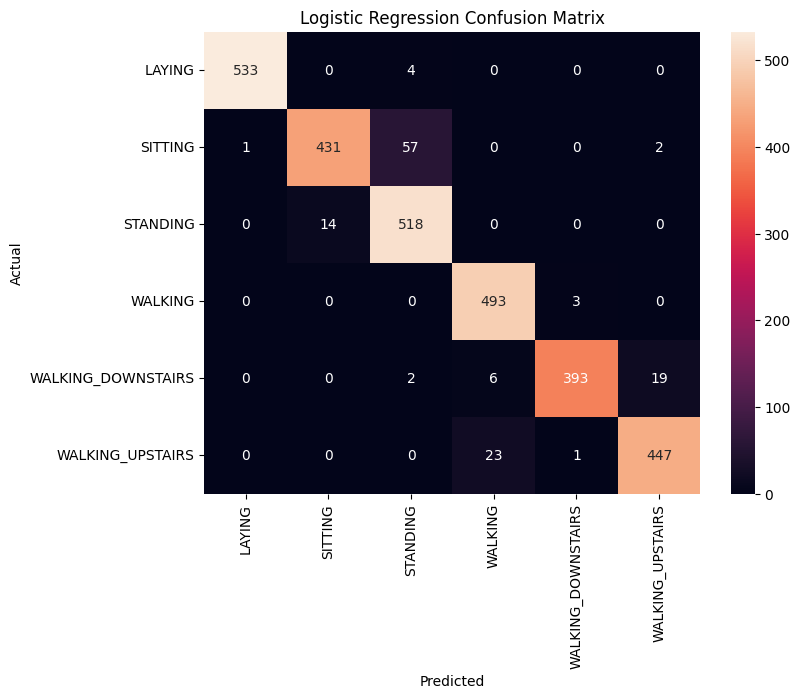

In [39]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=pipeline_log.named_steps['model'].classes_,
            yticklabels=pipeline_log.named_steps['model'].classes_)
plt.title("Logistic Regression Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

### Confusion Matrix Analysis

- Sitting and Standing show the highest confusion due to similar gravity orientation.
- Laying is classified almost perfectly due to distinct posture signals.
- Dynamic activities are better separated due to motion patterns captured by gyroscope features.

## Stratified Cross-Validation

We evaluate model stability using 5-fold Stratified Cross-Validation on the training set to ensure class balance across splits.

In [40]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline_log,
    X_train,
    y_train,
    cv=skf,
    scoring='f1_weighted'
)

print("Cross-Validation F1 Scores:", cv_scores)
print("Mean F1:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Cross-Validation F1 Scores: [0.98164624 0.99048266 0.98298071 0.98639558 0.98229074]
Mean F1: 0.9847591877045346
Std Dev: 0.003297958360213832


#Feature Importance (Logistic Regression)

In [41]:
model = pipeline_log.named_steps['model']

coef = np.mean(np.abs(model.coef_), axis=0)

top_indices = np.argsort(coef)[-15:]
top_features = X_train.columns[top_indices]

print("Top 15 Important Features:")
for f in top_features:
    print(f)

Top 15 Important Features:
tGravityAcc-min()-X
tGravityAcc-max()-X
tGravityAcc-mean()-X
angle(X,gravityMean)
tBodyAcc-correlation()-X,Y
tBodyGyroJerk-arCoeff()-X,2
tGravityAcc-energy()-Y
tBodyGyroJerk-entropy()-Y
angle(Y,gravityMean)
tBodyAccJerk-entropy()-Z
tGravityAcc-min()-Y
tGravityAcc-max()-Y
tGravityAcc-mean()-Y
fBodyGyro-entropy()-X
tBodyGyroJerk-entropy()-X


## Dimensionality Analysis using PCA

We apply PCA to analyze feature redundancy and understand how many principal components explain the majority of variance.

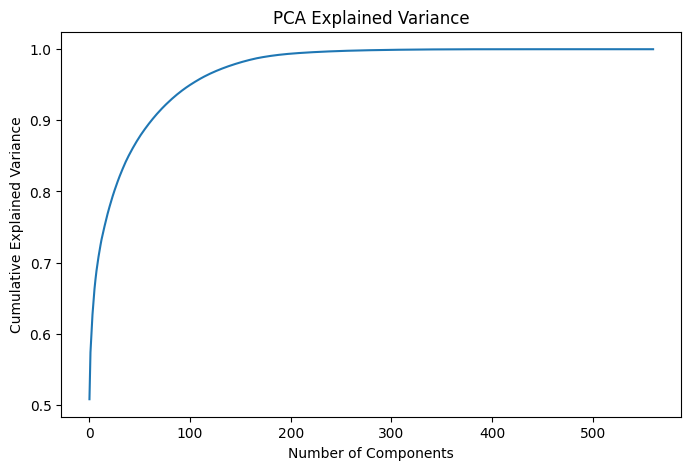

Components for 95% variance: 102


In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

pca = PCA()
pca.fit(X_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(explained_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

print("Components for 95% variance:",
      np.argmax(explained_variance >= 0.95) + 1)

#Observations:

- Logistic Regression outperformed Random Forest, suggesting near-linear separability of engineered features.
- Sitting and Standing show highest confusion due to similar gravity orientation.
- Gravity-based acceleration features dominate static posture classification.
- Gyroscope jerk features contribute to dynamic activity detection.
- PCA indicates high dimensional redundancy, with reduced components explaining majority variance.